# Análise Exploratória e Preparação de Dados — RaiaDrogasil

Este notebook realiza a extração, tipagem e análise exploratória dos dados de transações e cashback da RaiaDrogasil diretamente do Athena. O objetivo é validar a integridade estrutural, a volumetria temporal e o perfil de distribuição estatística (outliers) da série para embasar o pipeline de predição.

## Diretrizes de Modelagem e Dados

| Ponto | Decisão / Métrica |
|---|---|
| **Variáveis Alvo (Targets)** | Foram tipadas diretamente na query SQL (`CAST AS DOUBLE`) para mitigar erros de ingestão (`object`) que bloqueiam algoritmos preditivos. As targets são: `transacoes`, `cashin` e `cashout`. |
| **Prevenção de Data Leakage** | Variáveis comportamentais exatas (`status`, `filiado_recorrencia_compra`) foram descartadas do pipeline final, pois seus valores futuros são desconhecidos no momento da inferência. |
| **Sazonalidade e Features Exógenas** | Flags de dia da semana foram descartadas para evitar redundância com o cálculo nativo de Fourier do Prophet. Mantivemos apenas marcadores de liquidez não-lineares (`flg_inicio_mes`, `flg_fim_mes`, `flg_semana_pagamento`). |
| **Truncamento Histórico** | A série possui uma quebra estrutural severa anterior a meados de 2024. O escopo temporal do treino foi reduzido (Julho/2024 em diante) para refletir o patamar operacional atual do negócio. |
| **Integridade Operacional** | Remoção restrita das transações `'failed'` e `'expired'` em tempo de extração para isolar apenas os fluxos de sucesso e impedir contaminação do alvo. |

## Contexto e Instruções de Execução

Este notebook foi configurado para ser executado no ambiente Amazon SageMaker. A extração é feita via Athena (`pyathena`) utilizando autenticação STS, e o arquivo resultante é armazenado localmente para a etapa de modelagem.

In [16]:
# ── 1. Configurações de Ambiente e Conexão (AWS Athena) ──────────────────────
import os
import boto3
import pandas as pd
from pyathena import connect
from pyathena.pandas.util import as_pandas
import matplotlib.pyplot as plt
import seaborn as sns

DATALAKE_ROLE_ARN = "arn:aws:iam::670806723132:role/pdgt-maistodos-sagemaker-ai-models-prod-ia-admin"
ATHENA_DATABASE = "pdgt_maistodos_cashback"
S3_STAGING_DIR = "s3://todos-athena-us-east-1/todos-data-lake-sandbox/source=dbt/database=pdgt_sandbox_luis_silva/"
AWS_REGION = "us-east-1"

def get_athena_cursor():
    sts = boto3.client("sts", region_name=AWS_REGION)
    creds = sts.assume_role(
        RoleArn=DATALAKE_ROLE_ARN,
        RoleSessionName="sagemaker-athena-session"
    )["Credentials"]

    return connect(
        s3_staging_dir=S3_STAGING_DIR,
        schema_name=ATHENA_DATABASE,
        region_name=AWS_REGION,
        aws_access_key_id=creds["AccessKeyId"],
        aws_secret_access_key=creds["SecretAccessKey"],
        aws_session_token=creds["SessionToken"]
    ).cursor()

cursor = get_athena_cursor()

In [20]:
# ── 2. Extração de Dados, Tipagem e Features ─────────────────────────────────
query = """
SELECT 
    -- 1. Variável de Tempo Obrigatória
    dt_geracao_cashback AS ds,
    
    -- 2. Variáveis Alvo (Targets) Tipadas
    SUM(qtd_transacoes) AS transacoes,
    CAST(SUM(CASE WHEN tipo_transacao = 'cashin' THEN valor_cashback ELSE 0 END) AS DOUBLE) AS cashin,
    CAST(SUM(CASE WHEN tipo_transacao = 'cashout' THEN valor_cashback ELSE 0 END) AS DOUBLE) AS cashout,
    
    -- 3. Variáveis de Comportamento do Usuário 
    SUM(filiado_prim_compra) AS filiado_prim_compra,
    SUM(filiado_recorrencia_compra) AS filiado_recorrencia_compra,
    
    -- 4. Engenharia de Features Temporais (Mensais)
    CASE WHEN EXTRACT(DAY FROM dt_geracao_cashback) = 1 THEN 1 ELSE 0 END AS flg_inicio_mes,
    CASE WHEN EXTRACT(DAY FROM dt_geracao_cashback) >= 28 THEN 1 ELSE 0 END AS flg_fim_mes,
    CASE WHEN EXTRACT(DAY FROM dt_geracao_cashback) BETWEEN 4 AND 7 THEN 1 ELSE 0 END AS flg_semana_pagamento

FROM pdgt_maistodos_cashback.fl_report_cashback_origens_dash

WHERE 
    (LOWER(nv02_drill_origem_cluster) LIKE '%raia drogasil%' 
     OR LOWER(_nv2_drill) LIKE '%raia drogasil%')
    AND status NOT IN ('failed', 'expired')

GROUP BY 
    dt_geracao_cashback

ORDER BY 
    ds ASC;
"""

cursor.execute(query)
df = as_pandas(cursor)

display(df.head())

,ds,transacoes,cashin,cashout,filiado_prim_compra,filiado_recorrencia_compra,flg_inicio_mes,flg_fim_mes,flg_semana_pagamento
0,2021-09-07,1,30.00,0.0,1,0,0,0,1
1,2021-10-04,1350,4163.80,0.0,1305,0,0,0,1
2,2021-10-05,1936,5828.24,0.0,1839,0,0,0,1
3,2021-10-06,1764,5588.53,0.0,1647,0,0,0,1
4,2021-10-07,1777,5580.91,0.0,1651,0,0,0,1


In [21]:
# ── 3. Tratamento Temporal e Integridade ─────────────────────────────────────
# Assegurar que 'ds' é datetime para operações de série temporal
df['ds'] = pd.to_datetime(df['ds'])

# 1. Validação de Tipos e Integridade Básica
print("--- Tipos e Nulos ---")
print(df.info())
print("\nValores Nulos por Coluna:\n", df.isnull().sum())

--- Tipos e Nulos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1827 entries, 0 to 1826
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   ds                          1827 non-null   datetime64[ns]
 1   transacoes                  1827 non-null   int64         
 2   cashin                      1827 non-null   float64       
 3   cashout                     1827 non-null   float64       
 4   filiado_prim_compra         1827 non-null   int64         
 5   filiado_recorrencia_compra  1827 non-null   int64         
 6   flg_inicio_mes              1827 non-null   int64         
 7   flg_fim_mes                 1827 non-null   int64         
 8   flg_semana_pagamento        1827 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(6)
memory usage: 128.6 KB
None

Valores Nulos por Coluna:
 ds                            0
transacoes                    0


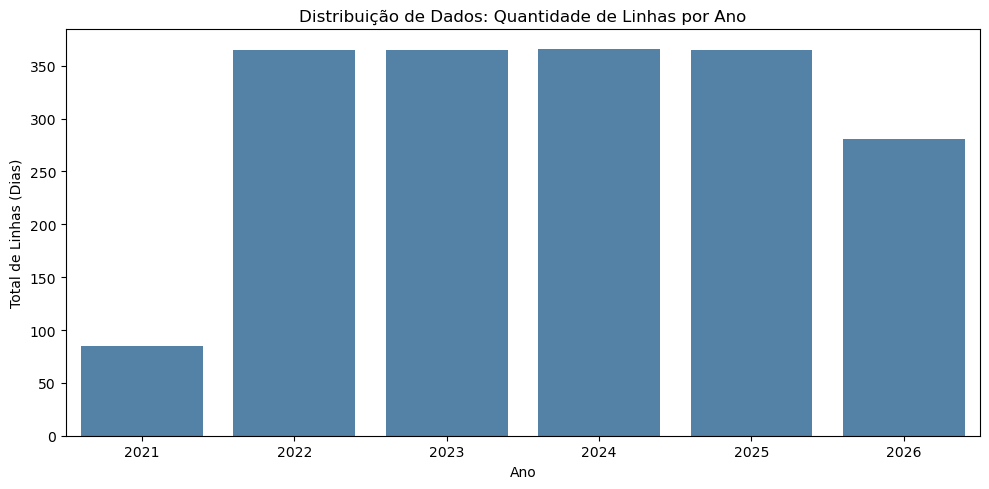

In [22]:
# ── 4. Distribuição Temporal Anual ───────────────────────────────────────────
# 2. Volumetria de dados por ano
distribuicao_ano = df['ds'].dt.year.value_counts().sort_index()

# Configuração do gráfico
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=distribuicao_ano.index, y=distribuicao_ano.values, color='steelblue')

plt.title('Distribuição de Dados: Quantidade de Linhas por Ano')
plt.xlabel('Ano')
plt.ylabel('Total de Linhas (Dias)')

plt.tight_layout()
plt.show()


--- Estatísticas Descritivas---


,count,mean,std,min,25%,50%,75%,max,coef_variacao
transacoes,1827.0,31778.632731,35091.722368,1.0,5835.500,16043.00,57564.000,335458.00,1.104255
cashin,1827.0,92145.806579,101983.185358,0.0,18180.175,43516.07,162567.295,981864.49,1.106759
cashout,1827.0,5698.392157,5121.766365,0.0,1018.170,4078.28,9577.950,22059.44,0.898809


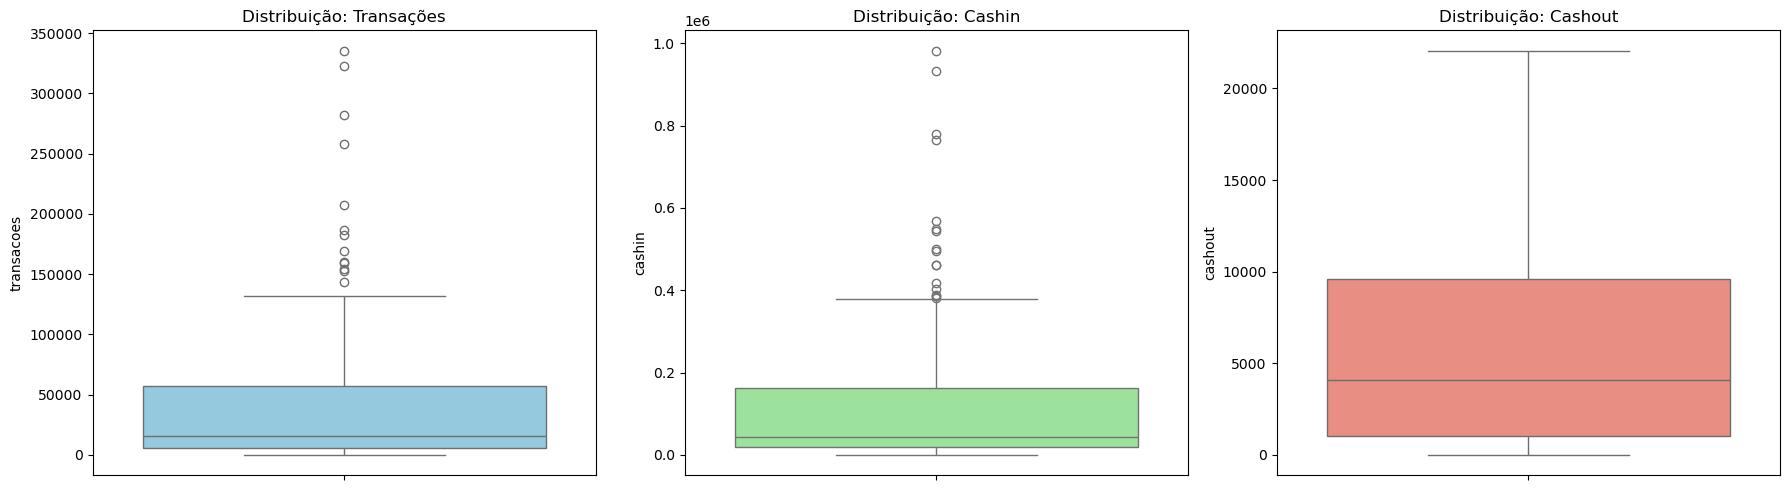

In [23]:
# ── 5. Avaliação Estatística e Outliers ──────────────────────────────────────
# 3. Análise Estatística e Alertas para o Modelo (Foco em STD)
print("\n--- Estatísticas Descritivas---")
stats_df = df[['transacoes', 'cashin', 'cashout']].describe().T
stats_df['coef_variacao'] = stats_df['std'] / stats_df['mean']
display(stats_df)

# 4. Análise de Distribuição e Outliers (Boxplots)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=df, y='transacoes', ax=axes[0], color='skyblue').set_title('Distribuição: Transações')
sns.boxplot(data=df, y='cashin', ax=axes[1], color='lightgreen').set_title('Distribuição: Cashin')
sns.boxplot(data=df, y='cashout', ax=axes[2], color='salmon').set_title('Distribuição: Cashout')
plt.tight_layout()
plt.show()

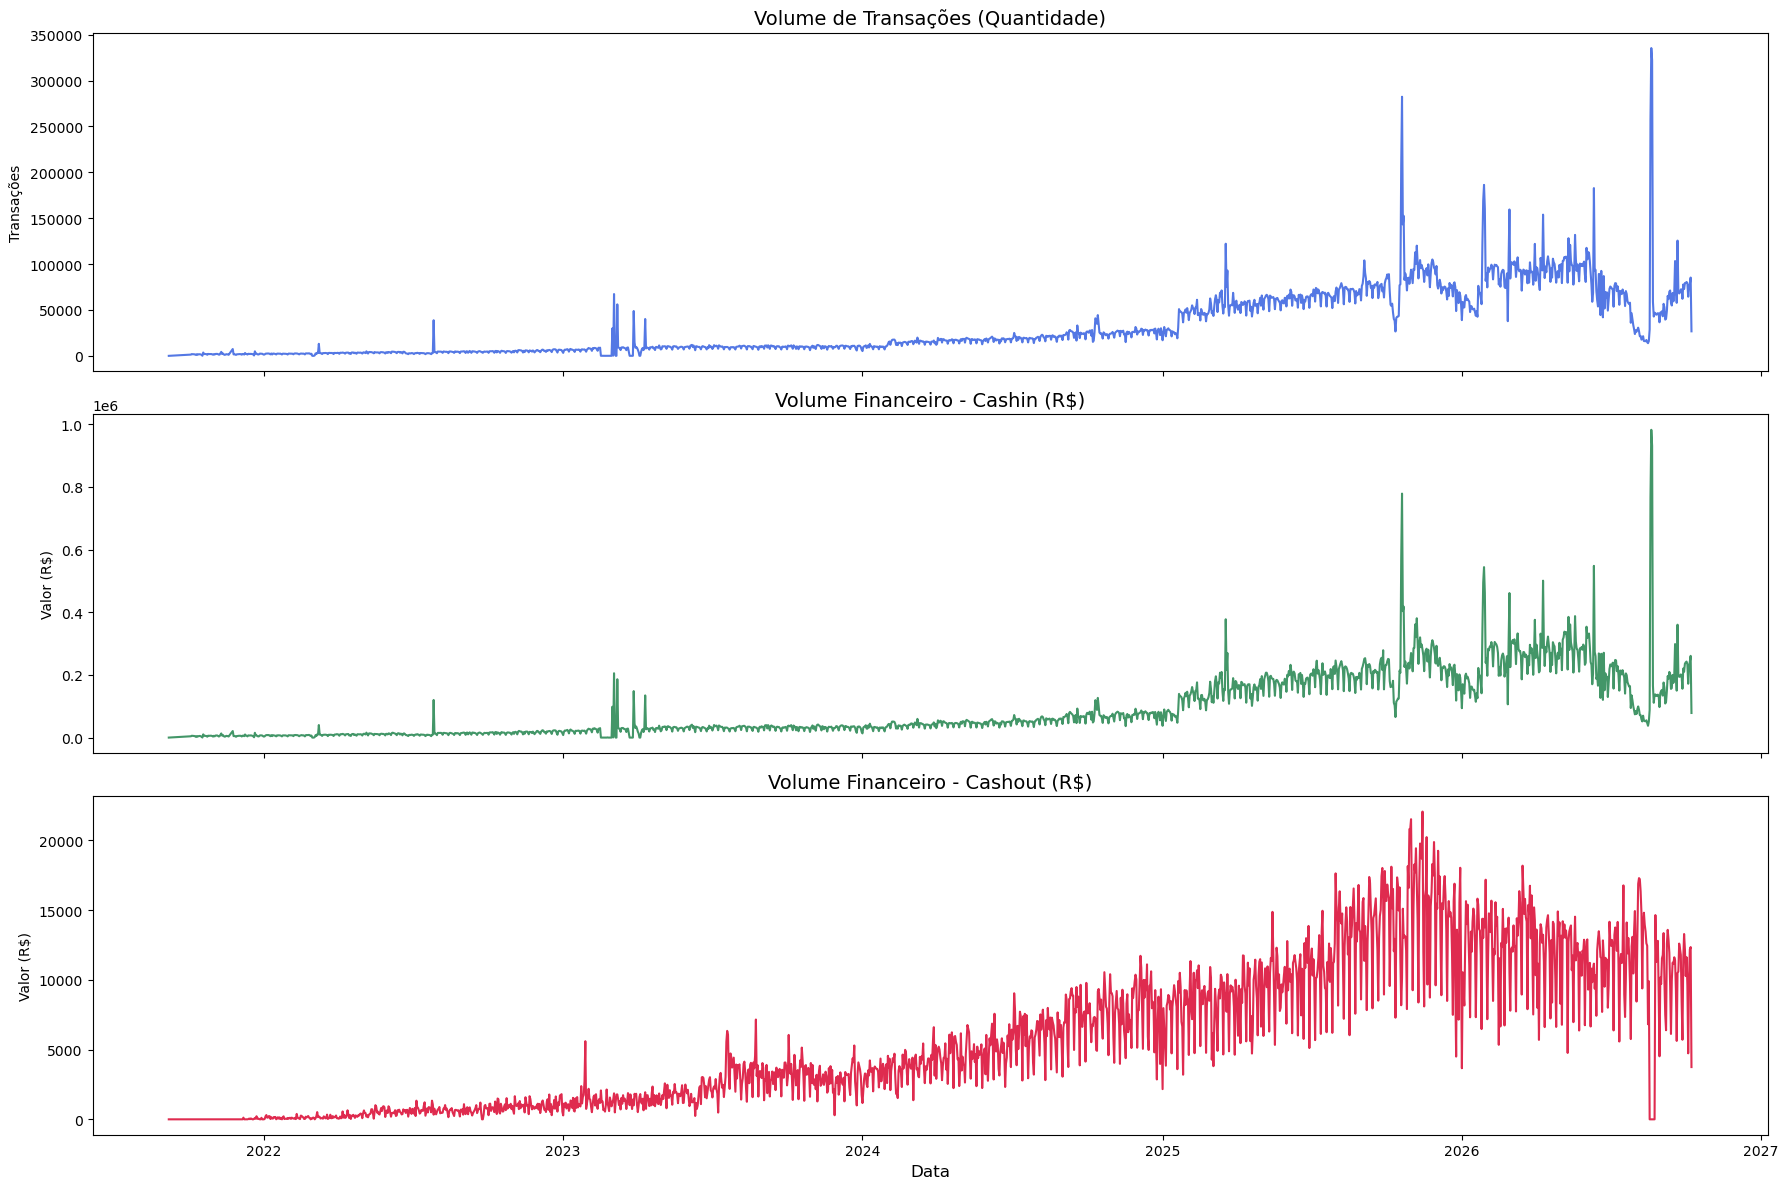

In [12]:
# 6. Comportamento Temporal e Sazonalidade (Visão Separada)
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

# Plot 1: Transações
sns.lineplot(data=df, x='ds', y='transacoes', ax=axes[0], color='royalblue', alpha=0.9)
axes[0].set_title('Volume de Transações (Quantidade)', fontsize=14)
axes[0].set_ylabel('Transações')

# Plot 2: Cashin
sns.lineplot(data=df, x='ds', y='cashin', ax=axes[1], color='seagreen', alpha=0.9)
axes[1].set_title('Volume Financeiro - Cashin (R$)', fontsize=14)
axes[1].set_ylabel('Valor (R$)')

# Plot 3: Cashout
sns.lineplot(data=df, x='ds', y='cashout', ax=axes[2], color='crimson', alpha=0.9)
axes[2].set_title('Volume Financeiro - Cashout (R$)', fontsize=14)
axes[2].set_ylabel('Valor (R$)')
axes[2].set_xlabel('Data', fontsize=12)

# Ajuste de layout para evitar sobreposição
plt.tight_layout()
plt.show()

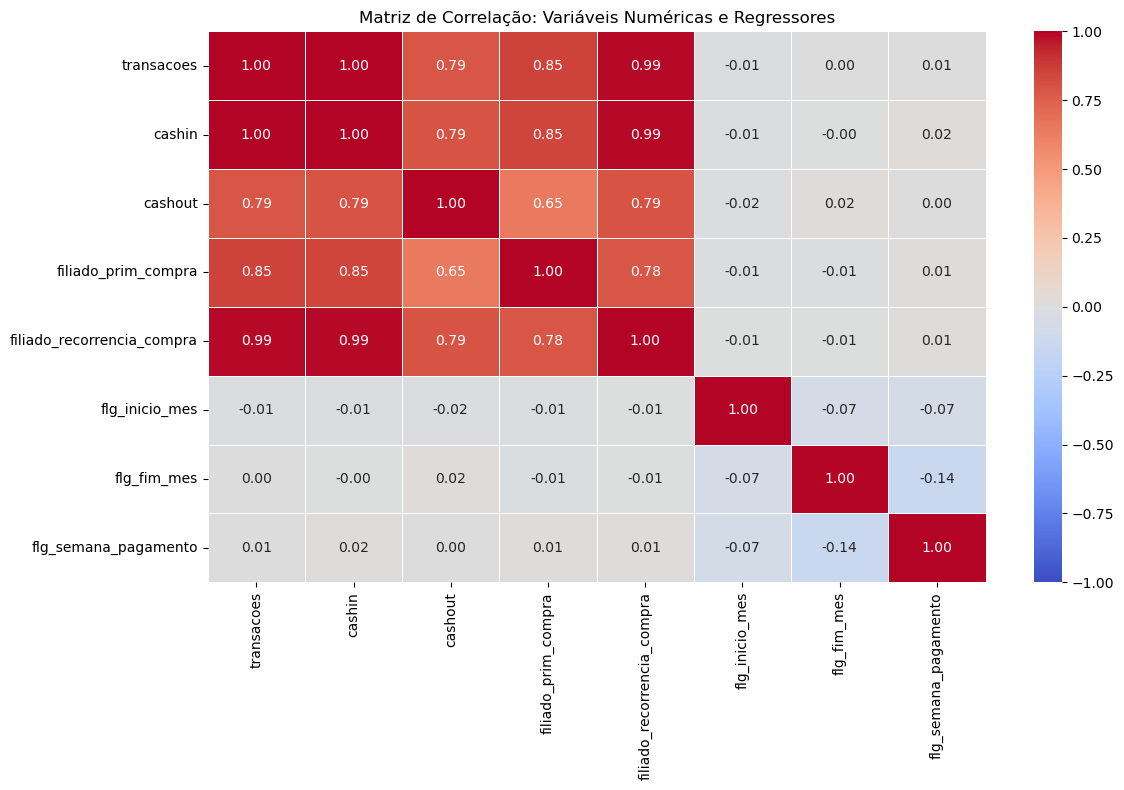

In [13]:
cols_numericas = df.select_dtypes(include=['number']).columns
matriz_corr = df[cols_numericas].corr()

# Configuração e plotagem do Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)

plt.title('Matriz de Correlação: Variáveis Numéricas e Regressores')
plt.tight_layout()
plt.show()

In [15]:
diretorio = "model-proj-tpv-rd/data"
caminho_arquivo = f"{diretorio}/fl_report_cashback_origens_dash.csv"

df.to_csv(caminho_arquivo, index=False)

print(f"Base salva com sucesso em: {caminho_arquivo}")

Base salva com sucesso em: model-proj-tpv-rd/data/fl_report_cashback_origens_dash.csv


In [17]:
# - Início: Meados de 2024 (ignora o histórico de baixo volume antes da quebra estrutural)
# - Fim: Setembro de 2026 (remove a queda a zero de Outubro/2026 causada por atraso de ingestão)
data_inicio = '2024-07-01'
data_fim = '2026-09-30'

# Aplicacao do Filtro
df_final = df[(df['ds'] >= data_inicio) & (df['ds'] <= data_fim)].copy()

# Remove colunas que causam Data Leakage, mantendo apenas Targets e Regressores Temporais
colunas_manter = [
    'ds', 'transacoes', 'cashin', 'cashout', 
    'flg_inicio_mes', 'flg_fim_mes', 'flg_semana_pagamento'
]
df_final = df_final[colunas_manter]

diretorio = "model-proj-tpv-rd/data"
caminho_arquivo_final = f"{diretorio}/fl_model_report.csv"

print(f"Base final consolidada com {len(df_final)} linhas.")
print(f"Período útil: {df_final['ds'].min().date()} a {df_final['ds'].max().date()}")
print(f"Arquivo salvo em: {caminho_arquivo_final}")

Base final consolidada com 822 linhas.
Período útil: 2024-07-01 a 2026-09-30
Arquivo salvo em: model-proj-tpv-rd/data/fl_model_report.csv


## Análise Crítica do Conjunto de Dados

1. **Eficiência de Ingestão:** A coerção explícita de tipos no Athena garantiu a recepção dos campos alvo (`cashin` e `cashout`) como variáveis numéricas perfeitas (`float64`), dispensando tratamentos de conversão dispendiosos em **Python** e isentando a amostra de valores nulos.

2. **Alta Variância na Geração (Cashin/Transações):** A série apresentou coeficientes de variação severos (superiores a 1.10) e distribuições deformadas à direita. O modelo revela máximos isolados que se dissociam agressivamente da média (ex: alcance de quase 1 milhão em um único dia frente à mediana de 43.516). Fatores exógenos (mapeamento de `holidays` / campanhas) devem ser configurados no Prophet para isolar esses eventos.

3. **Maturidade e Constância do Regaste (Cashout):** O `cashout` demonstrou-se menos suscetível a surtos massivos concentrados (coeficiente de variação de 0.89). Este padrão orgânico e diluído indica que o componente de sazonalidade semanal nativo do Prophet deverá atingir boa acurácia sem pesados ajustes exógenos.

4. **Queda a Zero por Atraso de Ingestão:** A série de Cashout sofreu uma queda abrupta nos dias finais (outubro/2026) devido a um atraso sistêmico de completude no Data Lake. O corte estrito limitando a base a setembro de 2026 preserva o conjunto de teste de anomalias irreais.